<a href="https://colab.research.google.com/github/sanjana-budha/data-analytics/blob/main/diagnosticanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

abandonment: 2
Internet Diagnosis: Poor Internet
Payment Diagnosis: High Payment Failure
Delivery Diagnosis: Delivery Charges Too High
Root Cause: Payment Gateway Issues


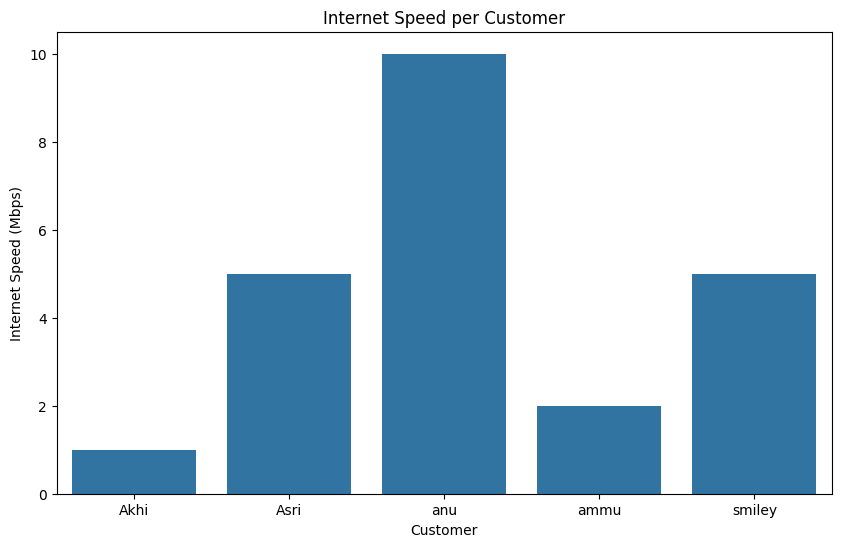

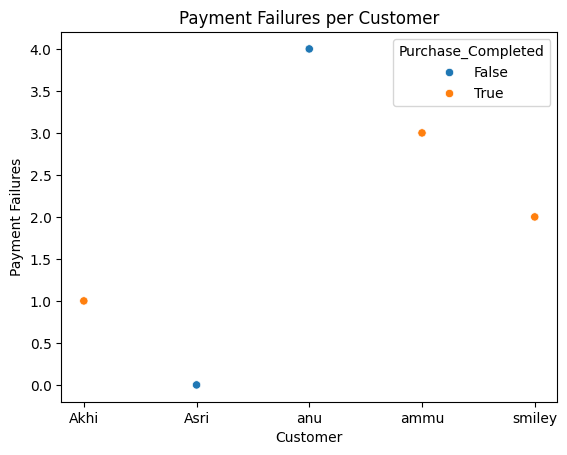

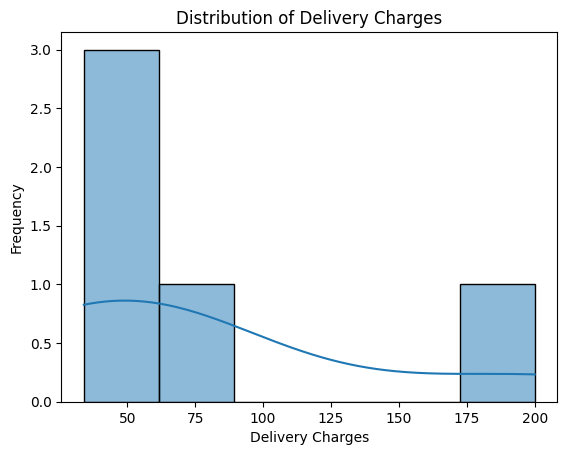

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cus_names = ["Akhi", "Asri", "anu", "ammu", "smiley"]
internet_speed = [1, 5, 10, 2, 5]
payment_failure = [1, 0, 4, 3, 2]
delivery_charges = [42, 34, 52, 67, 200]
purchase_completed = [True, False, False, True, True]

df = pd.DataFrame({
    "Customer": cus_names,
    "Internet_Speed": internet_speed,
    "Payment_Failure": payment_failure,
    "Delivery_Charges": delivery_charges,
    "Purchase_Completed": purchase_completed
})

#-------------TOTAL ABANDONMENT------------
Abandonment=purchase_completed.count(False)
print("abandonment:",Abandonment)

# ---------------- INTERNET DIAGNOSIS ----------------
avg_speed = np.mean(internet_speed)

if avg_speed < 5:
    internet_diagnosis = "Poor Internet"
elif avg_speed < 15:
    internet_diagnosis = "Moderate Internet"
else:
    internet_diagnosis = "Good Internet"
# ---------------- PAYMENT DIAGNOSIS ----------------
total_payment_failures = sum(payment_failure)

if total_payment_failures > 5:
    payment_diagnosis = "High Payment Failure"
else:
    payment_diagnosis = "Payment System Stable"

# ---------------- DELIVERY DIAGNOSIS ----------------
avg_delivery = np.mean(delivery_charges)

if avg_delivery > 50:
    delivery_diagnosis = "Delivery Charges Too High"
else:
    delivery_diagnosis = "Delivery Charges Acceptable"

# ---------------- ROOT CAUSE ANALYSIS ----------------
if total_payment_failures > 5:
    root_cause = "Payment Gateway Issues"
elif avg_speed < 5:
    root_cause = "Slow Internet"
elif avg_delivery > 50:
    root_cause = "High Delivery Charges"
else:
    root_cause = "No Major Issues"

# ---------------- OUTPUT ----------------
print("Internet Diagnosis:", internet_diagnosis)
print("Payment Diagnosis:", payment_diagnosis)
print("Delivery Diagnosis:", delivery_diagnosis)
print("Root Cause:", root_cause)

plt.figure(figsize=(10, 6))
sns.barplot(x='Customer', y='Internet_Speed', data=df,)
plt.title('Internet Speed per Customer')
plt.xlabel('Customer')
plt.ylabel('Internet Speed (Mbps)')
plt.show()

sns.scatterplot(x='Customer', y='Payment_Failure', data=df, hue='Purchase_Completed')
plt.title('Payment Failures per Customer')
plt.xlabel('Customer')
plt.ylabel('Payment Failures')
plt.show()

sns.histplot(x='Delivery_Charges', data=df, kde=True)
plt.title('Distribution of Delivery Charges')
plt.xlabel('Delivery Charges')
plt.ylabel('Frequency')
plt.show()

Customer Dataset
  Customer  Internet_Speed  Payment_Failure  Delivery_Charges  \
0     Akhi               2                3               200   
1     Asri              10                0                50   
2      Anu               1                4               250   
3     Ammu              15                0                40   
4   Smiley               3                2               180   

   Purchase_Completed  
0               False  
1                True  
2               False  
3                True  
4               False  

Total Abandonment: 3

Customers with Low Internet Speed (<5 Mbps):
Akhi - 2 Mbps
Anu - 1 Mbps
Smiley - 3 Mbps

Customers with Payment Failures:
Akhi - 3
Anu - 4
Smiley - 2

Customers with High Delivery Charges (>200):
Anu - 250

Root Cause Analysis:
Akhi - Abandonment due to Low Internet Speed
Anu - Abandonment due to Low Internet Speed
Smiley - Abandonment due to Low Internet Speed


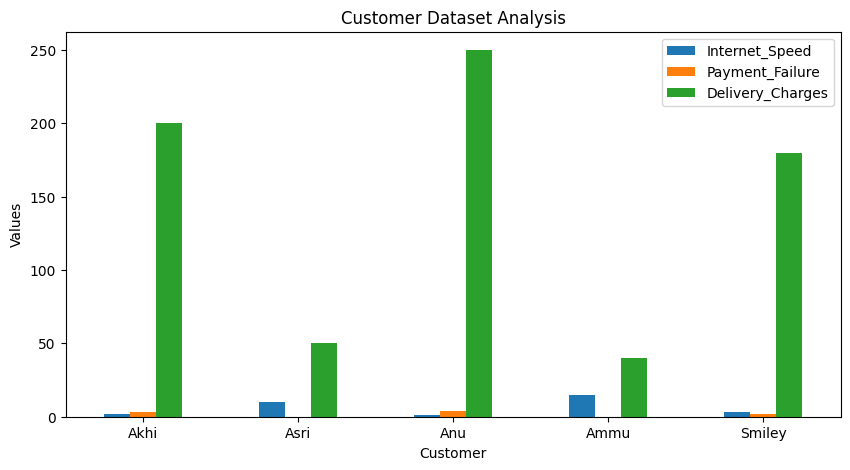

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
cus_names = ["Akhi", "Asri", "Anu", "Ammu", "Smiley"]
internet_speed = [2, 10, 1, 15, 3]
payment_failure = [3, 0, 4, 0, 2]
delivery_charges = [200, 50, 250, 40, 180]
purchase_completed = [False, True, False, True, False]

# Create DataFrame
df = pd.DataFrame({
    "Customer": cus_names,
    "Internet_Speed": internet_speed,
    "Payment_Failure": payment_failure,
    "Delivery_Charges": delivery_charges,
    "Purchase_Completed": purchase_completed
})

print("Customer Dataset")
print(df)

# Total Abandonment
total_abandonment = purchase_completed.count(False)
print("\nTotal Abandonment:", total_abandonment)

# ---------------- INTERNET DIAGNOSIS ----------------
print("\nCustomers with Low Internet Speed (<5 Mbps):")
for i in range(len(cus_names)):
    if internet_speed[i] < 5:
        print(cus_names[i], "-", internet_speed[i], "Mbps")

# ---------------- PAYMENT DIAGNOSIS ----------------
print("\nCustomers with Payment Failures:")
for i in range(len(cus_names)):
    if payment_failure[i] > 0:
        print(cus_names[i], "-", payment_failure[i])

# ---------------- DELIVERY DIAGNOSIS ----------------
print("\nCustomers with High Delivery Charges (>200):")
for i in range(len(cus_names)):
    if delivery_charges[i] > 200:
        print(cus_names[i], "-", delivery_charges[i])

# ---------------- ROOT CAUSE ANALYSIS ----------------
print("\nRoot Cause Analysis:")
for i in range(len(cus_names)):
    if purchase_completed[i] == False:
        if internet_speed[i] < 5:
            print(cus_names[i], "- Abandonment due to Low Internet Speed")
        elif payment_failure[i] > 0:
            print(cus_names[i], "- Abandonment due to Payment Failure")
        elif delivery_charges[i] > 150:
            print(cus_names[i], "- Abandonment due to High Delivery Charges")

# ---------------- VISUALIZATION ----------------
df.plot(
    x="Customer",
    y=["Internet_Speed", "Payment_Failure", "Delivery_Charges"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Customer Dataset Analysis")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os

# ---------------- DOWNLOAD DATASET ----------------
path = kagglehub.dataset_download("sandipshendage2210/list-of-orders")

print("Dataset Path:", path)

# Show files in dataset folder
files = os.listdir(path)
print("\nFiles in Dataset Folder:")
print(files)

# ---------------- LOAD CSV ----------------
csv_file = os.path.join(path, "List of Orders.csv")

df = pd.read_csv(csv_file)

print("\nDATASET")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

# ---------------- SELECT SALES COLUMN ----------------
# Change this if your dataset uses a different column name
amount_col = "Amount"

if amount_col not in df.columns:
    print(f"\nColumn '{amount_col}' not found.")
    print("Available Columns:")
    print(df.columns.tolist())
    raise ValueError("Please update amount_col with the correct column name.")

# ---------------- TOTAL ORDERS ----------------
total_orders = len(df)
print("\nTotal Orders:", total_orders)

# ---------------- CATEGORY ANALYSIS ----------------
print("\nCATEGORY ANALYSIS")

category_analysis = df.groupby("Category")[amount_col].sum()

for category, value in category_analysis.items():
    print(category, ":", value)

# ---------------- STATE ANALYSIS ----------------
print("\nSTATE ANALYSIS")

state_analysis = df.groupby("State")[amount_col].sum()

for state, value in state_analysis.items():
    print(state, ":", value)

# ---------------- ROOT CAUSE ANALYSIS ----------------
print("\nROOT CAUSE ANALYSIS")

low_sales = category_analysis.sort_values().head(3)

for category, value in low_sales.items():
    print(f"{category} has low sales = {value}")

# ---------------- BAR CHART ----------------
plt.figure(figsize=(8, 5))

category_analysis.plot(
    kind="bar"
)

plt.title("Category Sales Analysis")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=0)
plt.show()

# ---------------- PIE CHART ----------------
plt.figure(figsize=(7, 7))

category_analysis.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Category Sales Distribution")
plt.ylabel("")
plt.show()

Using Colab cache for faster access to the 'list-of-orders' dataset.
Dataset Path: /kaggle/input/list-of-orders

Files in Dataset Folder:
['List of Orders.csv']

DATASET
  Order ID  Order Date CustomerName           State       City
0  B-25601  01-04-2018       Bharat         Gujarat  Ahmedabad
1  B-25602  01-04-2018        Pearl     Maharashtra       Pune
2  B-25603  03-04-2018        Jahan  Madhya Pradesh     Bhopal
3  B-25604  03-04-2018       Divsha       Rajasthan     Jaipur
4  B-25605  05-04-2018      Kasheen     West Bengal    Kolkata

Columns:
['Order ID', 'Order Date', 'CustomerName', 'State', 'City']

Column 'Amount' not found.
Available Columns:
['Order ID', 'Order Date', 'CustomerName', 'State', 'City']


ValueError: Please update amount_col with the correct column name.